
===== Dataset: burma14 (Cities: 14) =====
ACO Best Distance: 31.23


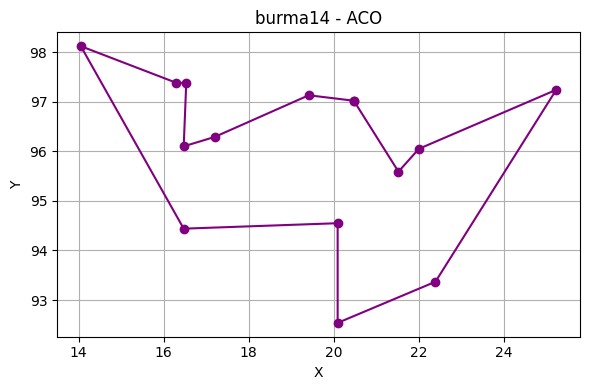

GSO Best Distance: 50.01


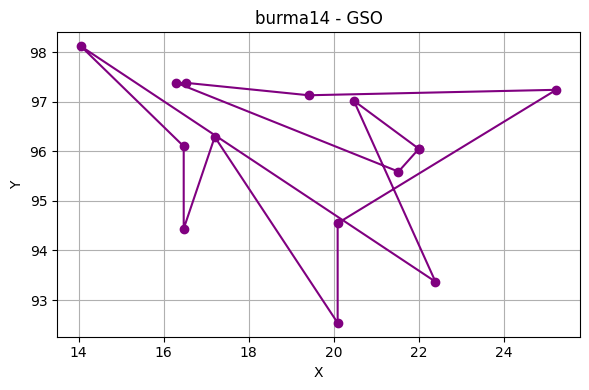

GA Best Distance: 31.23


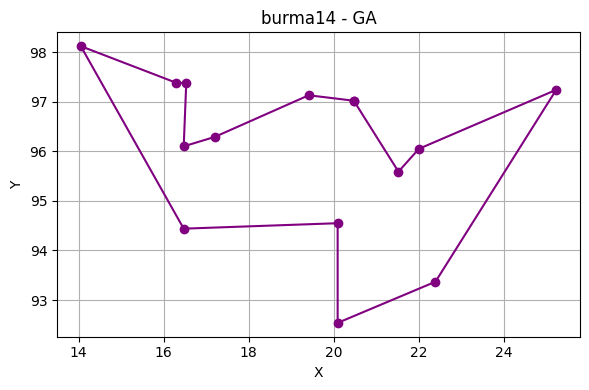


===== Dataset: berlin52 (Cities: 52) =====
ACO Best Distance: 7698.88


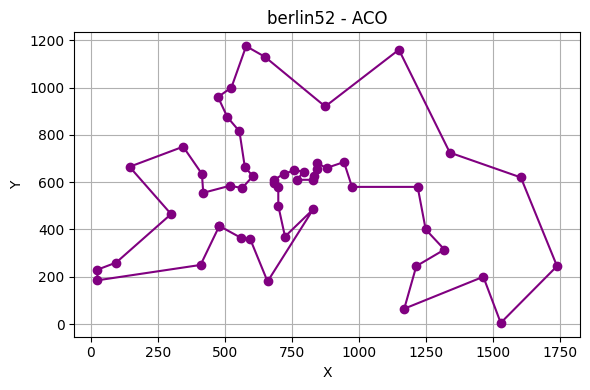

GSO Best Distance: 25616.57


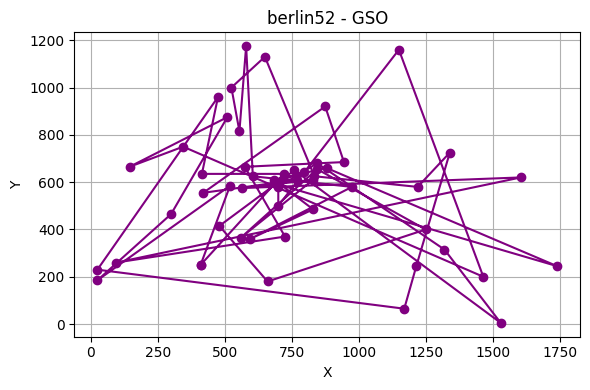

GA Best Distance: 13176.45


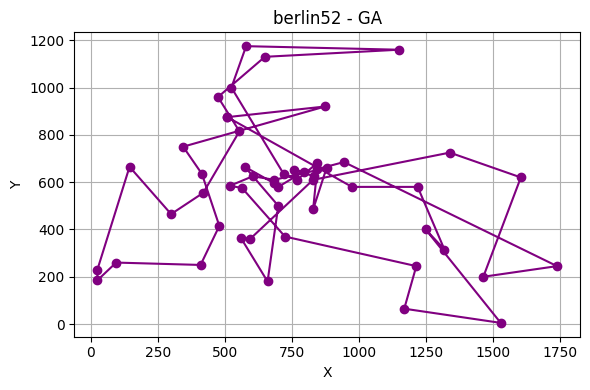


===== Dataset: bier127-tsp.txt (Cities: 127) =====
ACO Best Distance: 128710.32


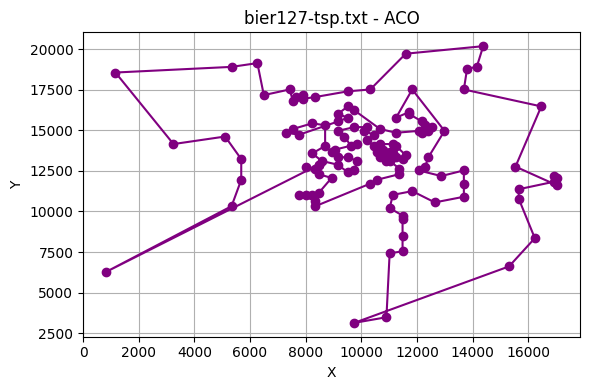

GSO Best Distance: 586562.35


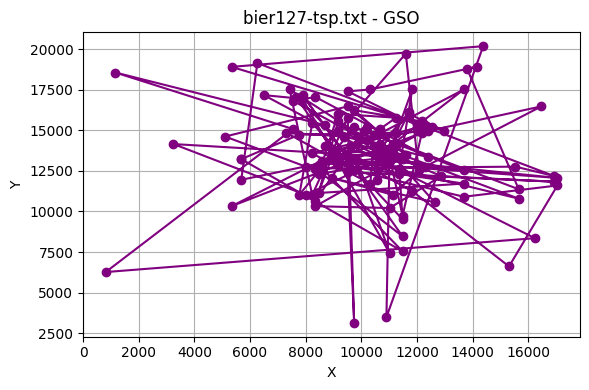

GA Best Distance: 338101.99


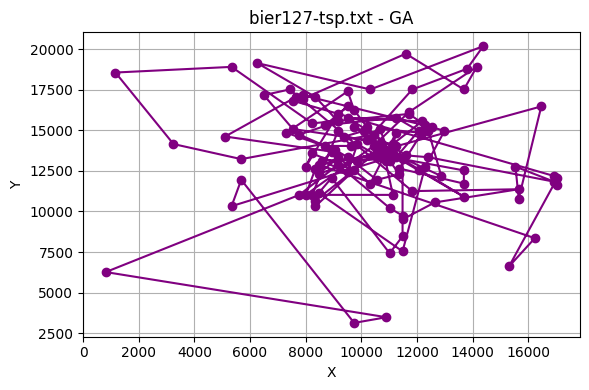

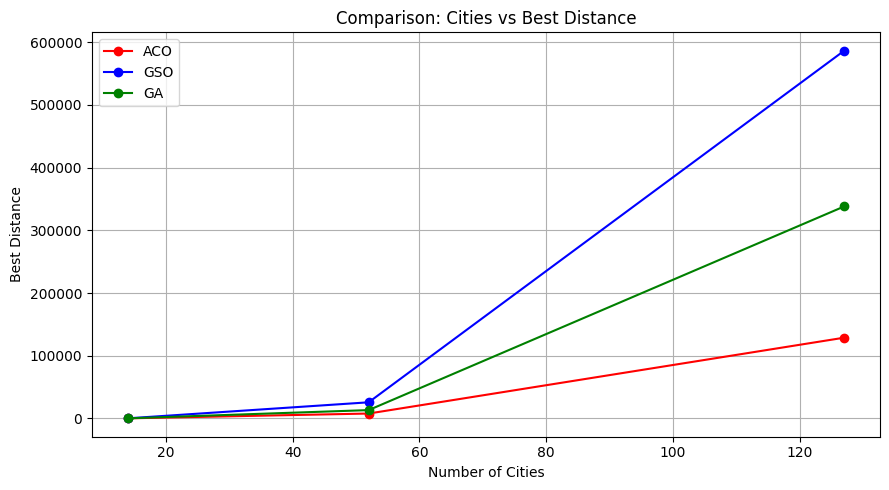

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
import os

# ---------------------- Utility Functions ----------------------
def load_tsp(filepath):
    coords = []
    with open(filepath, 'r') as file:
        start = False
        for line in file:
            if line.strip() == "NODE_COORD_SECTION":
                start = True
                continue
            if line.strip() == "EOF":
                break
            if start:
                parts = line.strip().split()
                if len(parts) >= 3:
                    coords.append((float(parts[1]), float(parts[2])))
    return coords

def calculate_distance_matrix(coords):
    n = len(coords)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist_matrix[i][j] = np.linalg.norm(np.array(coords[i]) - np.array(coords[j]))
    return dist_matrix

def plot_tour(coords, tour, title):
    tour_coords = [coords[i] for i in tour] + [coords[tour[0]]]
    x, y = zip(*tour_coords)
    plt.figure(figsize=(6, 4))
    plt.plot(x, y, 'o-', color='purple')
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ---------------------- Ant Colony Optimization ----------------------
def ACO(distance_matrix, n_ants=10, n_iterations=100, alpha=1.0, beta=5.0, evaporation=0.5, Q=100):
    n = len(distance_matrix)
    pheromone = np.ones((n, n))
    best_tour = None
    best_distance = float('inf')

    for _ in range(n_iterations):
        all_tours = []
        all_distances = []

        for _ in range(n_ants):
            tour = [random.randint(0, n-1)]
            while len(tour) < n:
                current = tour[-1]
                probs = []
                for j in range(n):
                    if j not in tour:
                        tau = pheromone[current][j] ** alpha
                        eta = (1 / distance_matrix[current][j]) ** beta
                        probs.append((j, tau * eta))
                total = sum(p for _, p in probs)
                r = random.uniform(0, total)
                acc = 0.0
                for city, prob in probs:
                    acc += prob
                    if acc >= r:
                        tour.append(city)
                        break
            all_tours.append(tour)
            d = sum(distance_matrix[tour[i]][tour[i+1]] for i in range(n-1)) + distance_matrix[tour[-1]][tour[0]]
            all_distances.append(d)

            if d < best_distance:
                best_distance = d
                best_tour = tour

        pheromone *= (1 - evaporation)
        for tour, d in zip(all_tours, all_distances):
            for i in range(n):
                pheromone[tour[i]][tour[(i+1)%n]] += Q / d

    return best_tour, best_distance

# ---------------------- Glowworm Swarm Optimization ----------------------
def GSO(coords, iterations=40, population_size=30):
    n = len(coords)
    luciferin = np.random.rand(population_size)
    population = [list(np.random.permutation(n)) for _ in range(population_size)]

    def fitness(tour):
        return 1 / (sum(np.linalg.norm(np.array(coords[tour[i]]) - np.array(coords[tour[i+1]])) for i in range(n-1)) +
                    np.linalg.norm(np.array(coords[tour[-1]]) - np.array(coords[tour[0]])))

    best_tour = None
    best_distance = float("inf")

    for _ in range(iterations):
        for i in range(population_size):
            neighbors = [j for j in range(population_size) if luciferin[j] > luciferin[i]]
            if neighbors:
                j = max(neighbors, key=lambda k: luciferin[k])
                new_tour = population[j][:]
                idx1, idx2 = sorted(random.sample(range(n), 2))
                new_tour[idx1:idx2] = reversed(new_tour[idx1:idx2])
                new_fit = fitness(new_tour)
                if new_fit > fitness(population[i]):
                    population[i] = new_tour[:]
                    luciferin[i] = new_fit

        for i in range(population_size):
            d = 1 / fitness(population[i])
            if d < best_distance:
                best_distance = d
                best_tour = population[i][:]

    return best_tour, best_distance

# ---------------------- Genetic Algorithm ----------------------
def GA(distance_matrix, population_size=50, generations=100, mutation_rate=0.2):
    n = len(distance_matrix)
    def create_individual():
        return list(np.random.permutation(n))

    def fitness(ind):
        return 1 / (sum(distance_matrix[ind[i]][ind[i+1]] for i in range(n-1)) + distance_matrix[ind[-1]][ind[0]])

    def crossover(parent1, parent2):
        start, end = sorted(random.sample(range(n), 2))
        middle = parent1[start:end]
        rest = [x for x in parent2 if x not in middle]
        return rest[:start] + middle + rest[start:]

    def mutate(ind):
        if random.random() < mutation_rate:
            i, j = random.sample(range(n), 2)
            ind[i], ind[j] = ind[j], ind[i]

    population = [create_individual() for _ in range(population_size)]
    best_individual = None
    best_distance = float("inf")

    for _ in range(generations):
        population.sort(key=lambda x: -fitness(x))
        new_population = population[:10]  # elitism
        while len(new_population) < population_size:
            p1, p2 = random.sample(population[:25], 2)
            child = crossover(p1, p2)
            mutate(child)
            new_population.append(child)
        population = new_population

        current_best = population[0]
        current_distance = 1 / fitness(current_best)
        if current_distance < best_distance:
            best_distance = current_distance
            best_individual = current_best

    return best_individual, best_distance

# ---------------------- Run on Dataset ----------------------
def run_on_dataset(filepath):
    coords = load_tsp(filepath)
    dist_matrix = calculate_distance_matrix(coords)
    name = os.path.basename(filepath).replace('.tsp', '')
    print(f"\n===== Dataset: {name} (Cities: {len(coords)}) =====")

    best_tour_aco, best_dist_aco = ACO(dist_matrix)
    print(f"ACO Best Distance: {best_dist_aco:.2f}")
    plot_tour(coords, best_tour_aco, f"{name} - ACO")

    best_tour_gso, best_dist_gso = GSO(coords)
    print(f"GSO Best Distance: {best_dist_gso:.2f}")
    plot_tour(coords, best_tour_gso, f"{name} - GSO")

    best_tour_ga, best_dist_ga = GA(dist_matrix)
    print(f"GA Best Distance: {best_dist_ga:.2f}")
    plot_tour(coords, best_tour_ga, f"{name} - GA")

    return len(coords), best_dist_aco, best_dist_gso, best_dist_ga

# ---------------------- Main Execution ----------------------
dataset_paths = ['/content/burma14.tsp','/content/berlin52.tsp', '/content/bier127-tsp.txt',]  # You can add more

cities = []
aco_dists = []
gso_dists = []
ga_dists = []

for path in dataset_paths:
    if os.path.exists(path):
        n, d1, d2, d3 = run_on_dataset(path)
        cities.append(n)
        aco_dists.append(d1)
        gso_dists.append(d2)
        ga_dists.append(d3)
    else:
        print(f"File not found: {path}")

# Final Comparison Plot
plt.figure(figsize=(9, 5))
plt.plot(cities, aco_dists, 'o-r', label="ACO")
plt.plot(cities, gso_dists, 'o-b', label="GSO")
plt.plot(cities, ga_dists, 'o-g', label="GA")
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("Comparison: Cities vs Best Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### **This the code I am using**

In [ ]:
def read_tsp_file(file_path):
    coords = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        start_index = 0
        for i, line in enumerate(lines):
            if line.strip() == 'NODE_COORD_SECTION':
                start_index = i + 1
                break
        for line in lines[start_index:]:
            if line.strip() == 'EOF':
                break
            parts = line.strip().split()
            if len(parts) >= 3:
                x, y = float(parts[1]), float(parts[2])
                coords.append((x, y))
    return coords


In [ ]:
def aco(coords, n_ants=30, iterations=50, alpha=1.0, beta=2.0, evaporation_rate=0.5, q=100):
    """
    A simple implementation of the Ant Colony Optimization algorithm for solving TSP.
    """
    n = len(coords)
    # Initialize pheromone matrix
    pheromone = np.ones((n, n))

    best_path = None
    best_distance = float('inf')

    for iter in range(iterations):
        paths = []  # Store paths for all ants
        distances = []  # Store distances for all ants

        for ant in range(n_ants):
            # Randomly start each ant from a city
            start_city = random.randint(0, n - 1)
            visited = [start_city]
            current_city = start_city

            # Construct a path
            for _ in range(n - 1):
                probabilities = []
                for next_city in range(n):
                    if next_city not in visited:
                        pheromone_val = pheromone[current_city][next_city] ** alpha
                        distance_val = (1.0 / calculateDistance([current_city, next_city])) ** beta
                        probabilities.append(pheromone_val * distance_val)
                    else:
                        probabilities.append(0)

                # Normalize the probabilities
                total = sum(probabilities)
                probabilities = [prob / total for prob in probabilities]

                # Choose the next city based on probabilities
                next_city = random.choices(range(n), probabilities)[0]
                visited.append(next_city)
                current_city = next_city

            # Complete the cycle (return to start city)
            visited.append(start_city)
            path_distance = calculateDistance(visited)
            paths.append(visited)
            distances.append(path_distance)

            if path_distance < best_distance:
                best_distance = path_distance
                best_path = visited

        # Update pheromone levels (evaporation and deposition)
        pheromone *= (1 - evaporation_rate)
        for path, dist in zip(paths, distances):
            for i in range(len(path) - 1):
                pheromone[path[i]][path[i + 1]] += q / dist

    return best_distance, best_path


In [ ]:
import random
import math
import time
import numpy as np
import os

# Global variables
n = 48
MAX_ITERATIONS = 200
NUM_GLOWWORMS = 50
GAMMA = 0.6

# Distance matrix representing distances between cities
distanceMatrix = []

class Glowworm:
    def __init__(self):
        self.tour = []
        self.brightness = 0.0

def calculateDistance(tour):
    totalDistance = 0.0
    for i in range(len(tour) - 1):
        if tour[i] < len(distanceMatrix) and tour[i + 1] < len(distanceMatrix):
            totalDistance += distanceMatrix[tour[i]][tour[i + 1]]
        else:
            print(f"Error: Invalid index in tour: {tour[i]} or {tour[i + 1]}")
            return float('inf')  # Return a large number for invalid paths
    totalDistance += distanceMatrix[tour[-1]][tour[0]]  # Return to starting city
    return totalDistance

def initializeGlowworms():
    glowworms = []
    for i in range(NUM_GLOWWORMS):
        newGlowworm = Glowworm()
        newGlowworm.tour = list(range(len(distanceMatrix)))
        random.shuffle(newGlowworm.tour[1:])  # Shuffle cities except starting city
        newGlowworm.brightness = 1.0 / calculateDistance(newGlowworm.tour)
        glowworms.append(newGlowworm)
    return glowworms

def swapTwoCities(tour, city1, city2):
    tour[city1], tour[city2] = tour[city2], tour[city1]

def gso(coords, n_agents=30, iterations=50, luciferin_decay=0.4, luciferin_enhance=0.6, neighborhood_range=4):
    global distanceMatrix
    n = len(coords)
    distanceMatrix = np.array([[euclidean_distance(coords[i], coords[j]) for j in range(n)] for i in range(n)])

    glowworms = initializeGlowworms()
    best_path, best_distance = None, float('inf')

    start_time = time.time()

    # Perform Glowworm Swarm Optimization
    for iter in range(MAX_ITERATIONS):
        # Update glowworm positions and brightness
        totalBrightness = sum(gw.brightness for gw in glowworms)
        for i in range(NUM_GLOWWORMS):
            # Glowworm Movement
            decisionRange = GAMMA * glowworms[i].brightness / totalBrightness
            neighborIndices = []

            for j in range(NUM_GLOWWORMS):
                if i != j and calculateDistance(glowworms[j].tour) < calculateDistance(glowworms[i].tour) + decisionRange:
                    neighborIndices.append(j)

            if neighborIndices:
                selectedNeighborIndex = random.choice(neighborIndices)
                city1 = random.randint(1, len(glowworms[i].tour) - 1)  # Exclude the starting city
                city2 = random.randint(1, len(glowworms[selectedNeighborIndex].tour) - 1)
                swapTwoCities(glowworms[i].tour, city1, city2)
                glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

            # Local Search (2-opt)
            bestTour = glowworms[i].tour
            bestDistance = calculateDistance(bestTour)
            for j in range(len(bestTour) - 1):
                for k in range(j + 1, len(bestTour)):
                    newTour = bestTour[:]
                    newTour[j:k+1] = reversed(newTour[j:k+1])
                    newDistance = calculateDistance(newTour)
                    if newDistance < bestDistance:
                        bestTour = newTour
                        bestDistance = newDistance
            glowworms[i].tour = bestTour
            glowworms[i].brightness = 1.0 / bestDistance

        # Sort glowworms based on brightness
        glowworms.sort(key=lambda x: x.brightness, reverse=True)

        # Update pheromone levels
        for i in range(NUM_GLOWWORMS):
            glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

    end_time = time.time()
    duration = (end_time - start_time) * 1000  # Duration in milliseconds
    print(f"Glowworm Swarm Optimization Time: {duration} ms")

    # Get the best solution
    bestGlowworm = max(glowworms, key=lambda gw: gw.brightness)

    # Output the best tour and distance
    best_distance = calculateDistance(bestGlowworm.tour)
    best_path = bestGlowworm.tour
    return best_distance, best_path

# Integration with existing code:
# Add aco, ga, pso, and gso distances to the main loop where you process datasets

# --- Main ---
dataset_paths = ['/content/burma14.tsp','/content/berlin52.tsp', '/content/bier127-tsp.txt']
cities, aco_dists, gso_dists, ga_dists, pso_dists = [], [], [], [], []

for path in dataset_paths:
    if os.path.exists(path):
        coords = read_tsp_file(path)
        n = len(coords)
        print(f"\nRunning on {path} with {n} cities")
        d1, _ = aco(coords)
        d2, _ = gso(coords)
        d3, _ = genetic_algorithm(coords)
        d4, _ = pso(coords)

        print(f"ACO: {d1:.2f}, GSO: {d2:.2f}, GA: {d3:.2f}, PSO: {d4:.2f}")
        cities.append(n)
        aco_dists.append(d1)
        gso_dists.append(d2)
        ga_dists.append(d3)
        pso_dists.append(d4)
    else:
        print(f"Dataset not found: {path}")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cities, aco_dists, 'o-r', label='ACO')
plt.plot(cities, gso_dists, 's-g', label='GSO')
plt.plot(cities, ga_dists, '^-b', label='GA')
plt.plot(cities, pso_dists, 'd-m', label='PSO')
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("TSP: Number of Cities vs Best Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Running on /content/burma14.tsp with 14 cities


IndexError: tuple index out of range

Glowworm Swarm Optimization Time: 204981.15992546082 ms


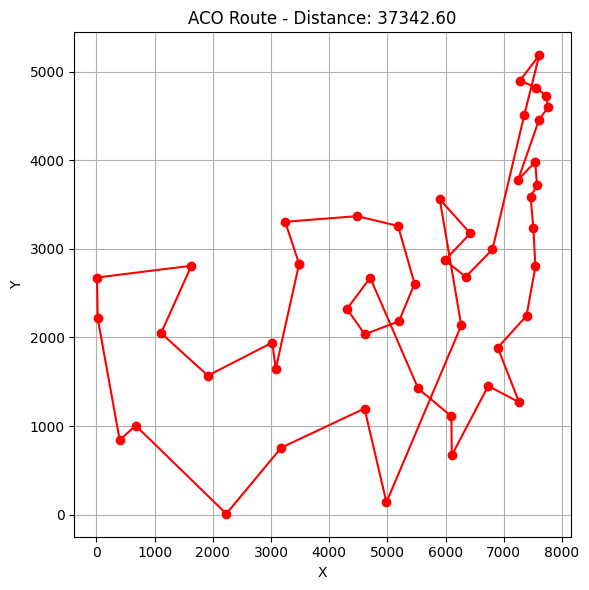

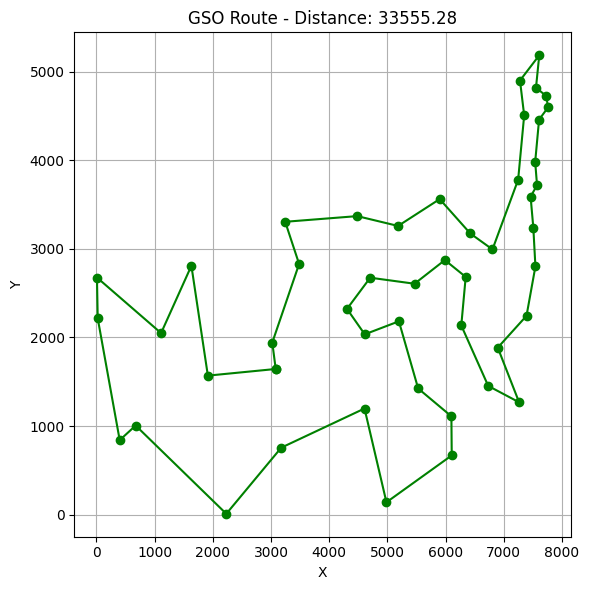

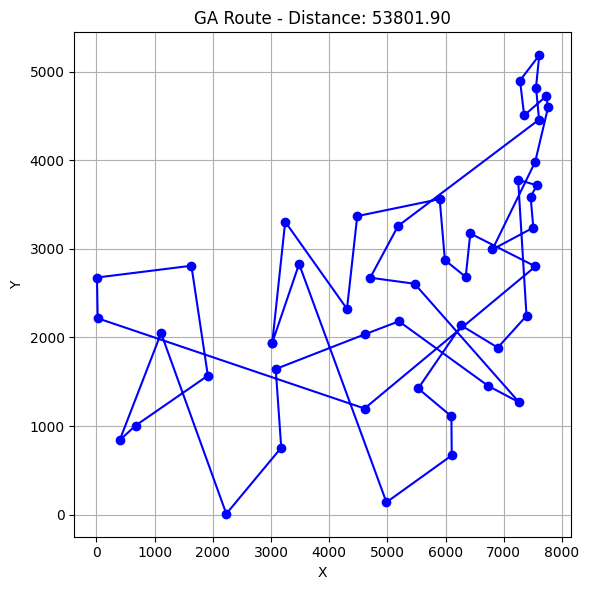

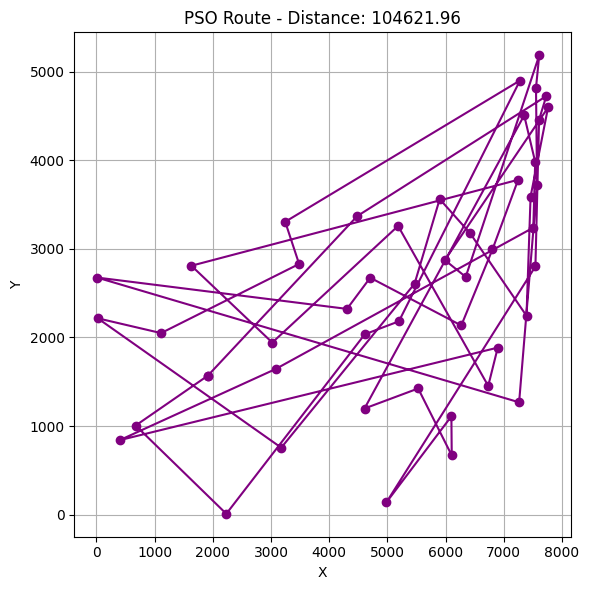

In [ ]:
# --- Visualize Routes for First Dataset Only ---
def plot_route(coords, tour, title, color='blue'):
    x = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    y = [coords[i][1] for i in tour] + [coords[tour[0]][1]]
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o', linestyle='-', color=color)
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Process and visualize if dataset exists
if os.path.exists(dataset_paths[0]):
    coords = read_tsp_file(dataset_paths[0])

    # Get tours from all 4 algorithms for first dataset
    aco_distance, aco_path = aco(coords)
    gso_distance, gso_path = gso(coords)
    ga_distance, ga_path = genetic_algorithm(coords)
    pso_distance, pso_path = pso(coords)

    plot_route(coords, aco_path, f"ACO Route - Distance: {aco_distance:.2f}", color='red')
    plot_route(coords, gso_path, f"GSO Route - Distance: {gso_distance:.2f}", color='green')
    plot_route(coords, ga_path, f"GA Route - Distance: {ga_distance:.2f}", color='blue')
    plot_route(coords, pso_path, f"PSO Route - Distance: {pso_distance:.2f}", color='purple')
else:
    print("First dataset not found.")


Glowworm Swarm Optimization Time: 206181.574344635 ms


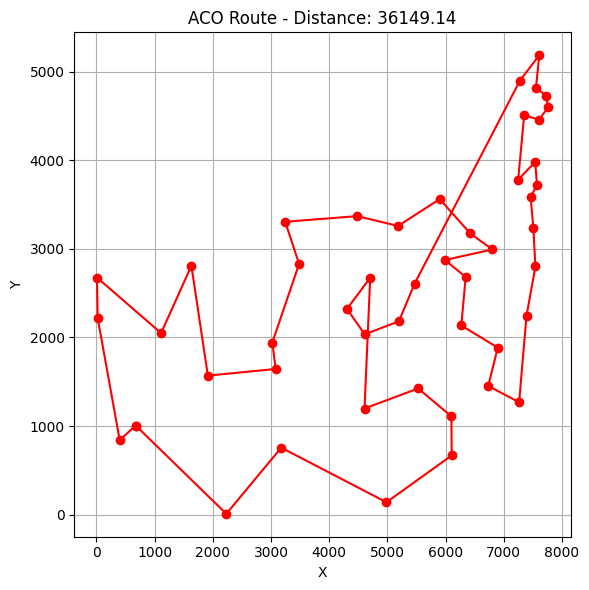

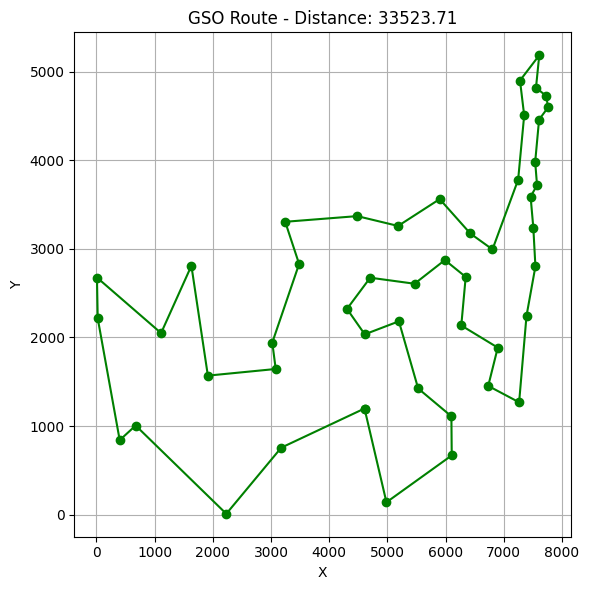

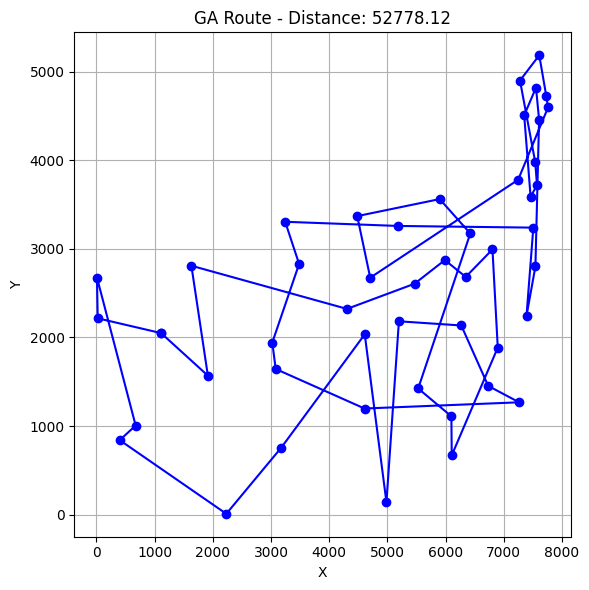

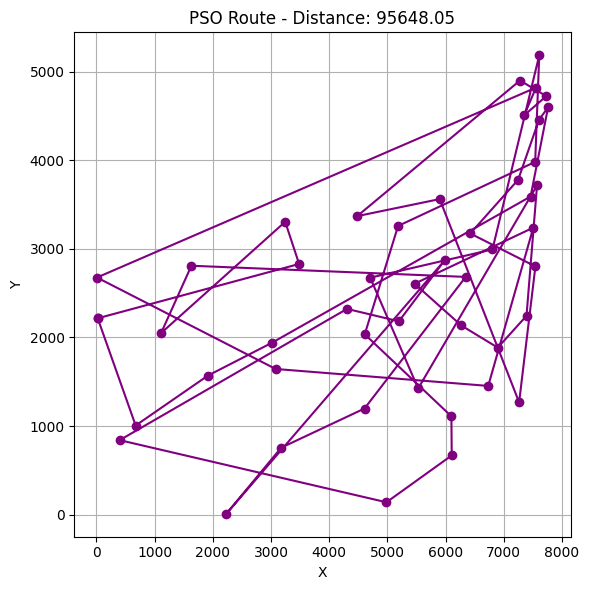

In [ ]:
# --- Visualize Routes for First Dataset Only ---
def plot_route(coords, tour, title, color='blue'):
    x = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    y = [coords[i][1] for i in tour] + [coords[tour[0]][1]]
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, marker='o', linestyle='-', color=color)
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Process and visualize if dataset exists
if os.path.exists(dataset_paths[2]):
    coords = read_tsp_file(dataset_paths[0])

    # Get tours from all 4 algorithms for first dataset
    aco_distance, aco_path = aco(coords)
    gso_distance, gso_path = gso(coords)
    ga_distance, ga_path = genetic_algorithm(coords)
    pso_distance, pso_path = pso(coords)

    plot_route(coords, aco_path, f"ACO Route - Distance: {aco_distance:.2f}", color='red')
    plot_route(coords, gso_path, f"GSO Route - Distance: {gso_distance:.2f}", color='green')
    plot_route(coords, ga_path, f"GA Route - Distance: {ga_distance:.2f}", color='blue')
    plot_route(coords, pso_path, f"PSO Route - Distance: {pso_distance:.2f}", color='purple')
else:
    print("First dataset not found.")



Running on /content/burma14.tsp with 14 cities
ACO: 31.80, GSO: 36.24, GA: 30.88, PSO: 35.21

Running on /content/berlin52.tsp with 52 cities
ACO: 7908.78, GSO: 25676.65, GA: 11546.18, PSO: 20184.82

Running on /content/bier127.tsp with 127 cities
ACO: 131500.86, GSO: 565977.16, GA: 334331.36, PSO: 517017.82


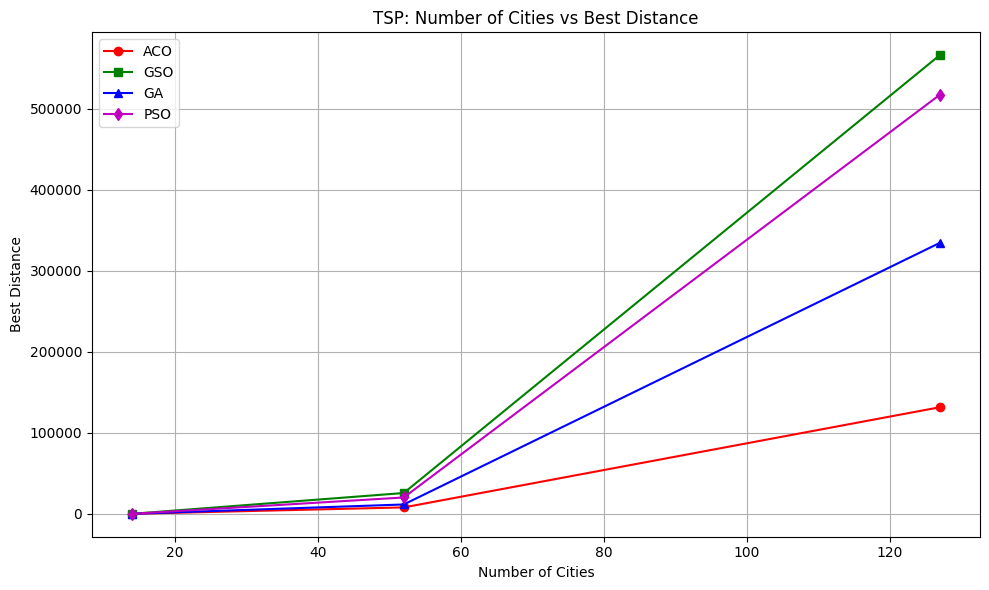

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math, random, os

# --- Helper Functions ---
def euclidean_distance(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def total_distance(path, cities):
    return sum(euclidean_distance(cities[path[i]], cities[path[(i + 1) % len(path)]]) for i in range(len(path)))

def read_tsp_file(filename):
    coords = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            # Skip empty lines or lines that are headers
            if line and not any(keyword in line.lower() for keyword in ['name', 'type', 'dimension', 'edge', 'locations']):
                # Check if the line contains numeric values and has at least 3 elements
                parts = line.split()
                if len(parts) >= 3 and parts[1].replace('.', '', 1).isdigit() and parts[2].replace('.', '', 1).isdigit():
                    _, x, y = parts[0], parts[1], parts[2]  # unpack the first 3 elements
                    coords.append((float(x), float(y)))
    return coords



# --- Ant Colony Optimization ---
def aco(coords, n_ants=10, n_iterations=50, alpha=1.0, beta=5.0, evaporation=0.5):
    n = len(coords)
    pheromone = np.ones((n, n))
    distances = np.array([[euclidean_distance(coords[i], coords[j]) for j in range(n)] for i in range(n)])
    best_path, best_distance = None, float('inf')

    for _ in range(n_iterations):
        paths, dists = [], []
        for _ in range(n_ants):
            unvisited = list(range(n))
            path = [unvisited.pop(random.randint(0, n - 1))]
            while unvisited:
                probs = []
                for city in unvisited:
                    pher = pheromone[path[-1]][city] ** alpha
                    heur = (1.0 / distances[path[-1]][city]) ** beta
                    probs.append(pher * heur)
                probs = probs / np.sum(probs)
                next_city = random.choices(unvisited, weights=probs)[0]
                unvisited.remove(next_city)
                path.append(next_city)
            d = total_distance(path, coords)
            paths.append(path)
            dists.append(d)
            if d < best_distance:
                best_distance, best_path = d, path
        for i in range(n):
            for j in range(n):
                pheromone[i][j] *= (1 - evaporation)
        for path, d in zip(paths, dists):
            for i in range(n):
                pheromone[path[i]][path[(i + 1) % n]] += 1.0 / d

    return best_distance, best_path

# --- Glowworm Swarm Optimization ---
def gso(coords, n_agents=30, iterations=50, luciferin_decay=0.4, luciferin_enhance=0.6, neighborhood_range=5):
    n = len(coords)
    agents = [random.sample(range(n), n) for _ in range(n_agents)]
    luciferins = [1.0] * n_agents
    best_path, best_distance = None, float('inf')

    for _ in range(iterations):
        for i in range(n_agents):
            d = total_distance(agents[i], coords)
            luciferins[i] = (1 - luciferin_decay) * luciferins[i] + luciferin_enhance / d

        new_agents = []
        for i in range(n_agents):
            neighbors = [j for j in range(n_agents) if i != j and total_distance(agents[j], coords) < total_distance(agents[i], coords)]
            if neighbors:
                j = random.choice(neighbors)
                point = random.randint(0, n - 1)
                new = agents[i][:]
                swap_index = new.index(agents[j][point])
                new[point], new[swap_index] = new[swap_index], new[point]
                new_agents.append(new)
            else:
                new_agents.append(agents[i])
        agents = new_agents

        for i in range(n_agents):
            d = total_distance(agents[i], coords)
            if d < best_distance:
                best_distance, best_path = d, agents[i]

    return best_distance, best_path

# --- Genetic Algorithm ---
def genetic_algorithm(coords, pop_size=100, generations=200, mutation_rate=0.01):
    def crossover(p1, p2):
        start, end = sorted(random.sample(range(len(p1)), 2))
        child = [-1] * len(p1)
        child[start:end] = p1[start:end]
        ptr = 0
        for i in range(len(p2)):
            if p2[i] not in child:
                while child[ptr] != -1:
                    ptr += 1
                child[ptr] = p2[i]
        return child

    def mutate(p):
        i, j = random.sample(range(len(p)), 2)
        p[i], p[j] = p[j], p[i]

    population = [random.sample(range(len(coords)), len(coords)) for _ in range(pop_size)]
    best_path, best_distance = None, float('inf')

    for _ in range(generations):
        population.sort(key=lambda x: total_distance(x, coords))
        if total_distance(population[0], coords) < best_distance:
            best_distance = total_distance(population[0], coords)
            best_path = population[0]
        new_pop = population[:10]
        while len(new_pop) < pop_size:
            p1, p2 = random.sample(population[:50], 2)
            child = crossover(p1, p2)
            if random.random() < mutation_rate:
                mutate(child)
            new_pop.append(child)
        population = new_pop

    return best_distance, best_path

# --- PSO ---
def pso(coords, n_particles=30, iterations=100):
    n = len(coords)
    particles = [random.sample(range(n), n) for _ in range(n_particles)]
    pbest = particles[:]
    pbest_scores = [total_distance(p, coords) for p in particles]
    gbest = min(pbest, key=lambda x: total_distance(x, coords))
    gbest_score = total_distance(gbest, coords)

    for _ in range(iterations):
        for i in range(n_particles):
            new = pbest[i][:]
            if random.random() < 0.5:
                swap_indices = random.sample(range(n), 2)
                new[swap_indices[0]], new[swap_indices[1]] = new[swap_indices[1]], new[swap_indices[0]]
            if total_distance(new, coords) < pbest_scores[i]:
                pbest[i] = new
                pbest_scores[i] = total_distance(new, coords)
        best_particle = min(pbest, key=lambda x: total_distance(x, coords))
        if total_distance(best_particle, coords) < gbest_score:
            gbest = best_particle
            gbest_score = total_distance(gbest, coords)

    return gbest_score, gbest

# --- Main ---
dataset_paths = ['/content/burma14.tsp','/content/berlin52.tsp','/content/bier127.tsp',]
cities, aco_dists, gso_dists, ga_dists, pso_dists = [], [], [], [], []

for path in dataset_paths:
    if os.path.exists(path):
        coords = read_tsp_file(path)
        n = len(coords)
        print(f"\nRunning on {path} with {n} cities")
        d1, _ = aco(coords)
        d2, _ = gso(coords)
        d3, _ = genetic_algorithm(coords)
        d4, _ = pso(coords)

        print(f"ACO: {d1:.2f}, GSO: {d2:.2f}, GA: {d3:.2f}, PSO: {d4:.2f}")
        cities.append(n)
        aco_dists.append(d1)
        gso_dists.append(d2)
        ga_dists.append(d3)
        pso_dists.append(d4)
    else:
        print(f"Dataset not found: {path}")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cities, aco_dists, 'o-r', label='ACO')
plt.plot(cities, gso_dists, 's-g', label='GSO')
plt.plot(cities, ga_dists, '^-b', label='GA')
plt.plot(cities, pso_dists, 'd-m', label='PSO')
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("TSP: Number of Cities vs Best Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Running on /content/burma14.tsp with 14 cities
Glowworm Swarm Optimization Time: 10086.62223815918 ms
ACO: 31.46, GSO: 30.88, GA: 32.43, PSO: 35.39

Running on /content/berlin52.tsp with 52 cities
Glowworm Swarm Optimization Time: 255217.05436706543 ms
ACO: 7949.95, GSO: 7544.37, GA: 12805.12, PSO: 19439.39

Running on /content/bier127.tsp with 127 cities
Glowworm Swarm Optimization Time: 3409415.363550186 ms
ACO: 129588.61, GSO: 120099.18, GA: 336747.15, PSO: 527733.51


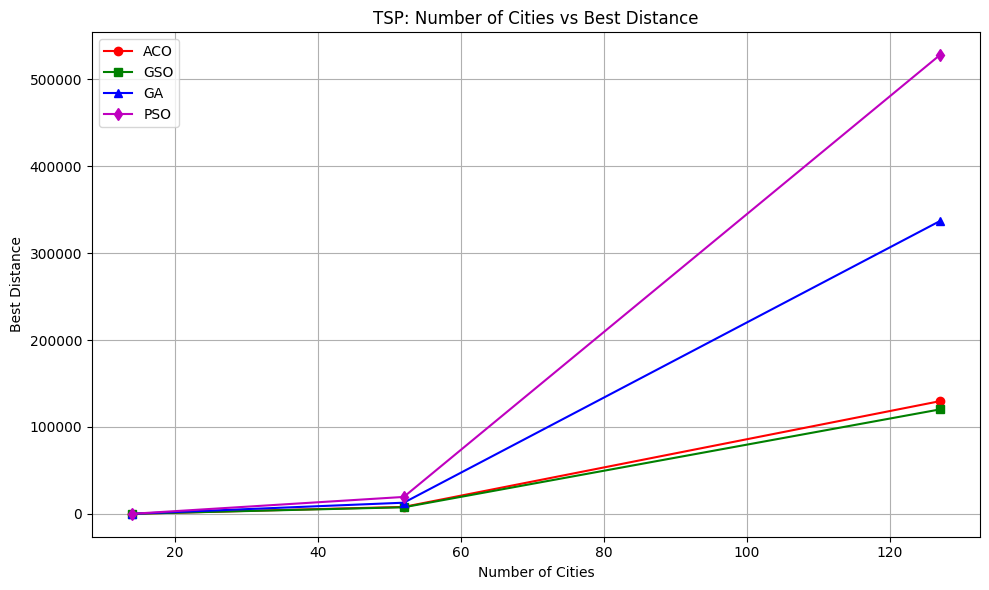

In [ ]:
import random
import math
import time
import numpy as np

# Global variables
n = 48
MAX_ITERATIONS = 200
NUM_GLOWWORMS = 50
GAMMA = 0.6

# Distance matrix representing distances between cities
distanceMatrix = []

class Glowworm:
    def __init__(self):
        self.tour = []
        self.brightness = 0.0

def calculateDistance(tour):
    totalDistance = 0.0
    for i in range(len(tour) - 1):
        totalDistance += distanceMatrix[tour[i]][tour[i + 1]]
    totalDistance += distanceMatrix[tour[-1]][tour[0]]  # Return to starting city
    return totalDistance

def initializeGlowworms():
    glowworms = []
    for i in range(NUM_GLOWWORMS):
        newGlowworm = Glowworm()
        newGlowworm.tour = list(range(len(distanceMatrix)))
        random.shuffle(newGlowworm.tour[1:])  # Shuffle cities except starting city
        newGlowworm.brightness = 1.0 / calculateDistance(newGlowworm.tour)
        glowworms.append(newGlowworm)
    return glowworms

def swapTwoCities(tour, city1, city2):
    tour[city1], tour[city2] = tour[city2], tour[city1]

def gso(coords, n_agents=30, iterations=50, luciferin_decay=0.4, luciferin_enhance=0.6, neighborhood_range=5):
    global distanceMatrix
    n = len(coords)
    distanceMatrix = np.array([[euclidean_distance(coords[i], coords[j]) for j in range(n)] for i in range(n)])

    glowworms = initializeGlowworms()
    best_path, best_distance = None, float('inf')

    start_time = time.time()

    # Perform Glowworm Swarm Optimization
    for iter in range(MAX_ITERATIONS):
        # Update glowworm positions and brightness
        totalBrightness = sum(gw.brightness for gw in glowworms)
        for i in range(NUM_GLOWWORMS):
            # Glowworm Movement
            decisionRange = GAMMA * glowworms[i].brightness / totalBrightness
            neighborIndices = []

            for j in range(NUM_GLOWWORMS):
                if i != j and calculateDistance(glowworms[j].tour) < calculateDistance(glowworms[i].tour) + decisionRange:
                    neighborIndices.append(j)

            if neighborIndices:
                selectedNeighborIndex = random.choice(neighborIndices)
                city1 = random.randint(1, len(glowworms[i].tour) - 1)  # Exclude the starting city
                city2 = random.randint(1, len(glowworms[selectedNeighborIndex].tour) - 1)
                swapTwoCities(glowworms[i].tour, city1, city2)
                glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

            # Local Search (2-opt)
            bestTour = glowworms[i].tour
            bestDistance = calculateDistance(bestTour)
            for j in range(len(bestTour) - 1):
                for k in range(j + 1, len(bestTour)):
                    newTour = bestTour[:]
                    newTour[j:k+1] = reversed(newTour[j:k+1])
                    newDistance = calculateDistance(newTour)
                    if newDistance < bestDistance:
                        bestTour = newTour
                        bestDistance = newDistance
            glowworms[i].tour = bestTour
            glowworms[i].brightness = 1.0 / bestDistance

        # Sort glowworms based on brightness
        glowworms.sort(key=lambda x: x.brightness, reverse=True)

        # Update pheromone levels
        for i in range(NUM_GLOWWORMS):
            glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

    end_time = time.time()
    duration = (end_time - start_time) * 1000  # Duration in milliseconds
    print(f"Glowworm Swarm Optimization Time: {duration} ms")

    # Get the best solution
    bestGlowworm = max(glowworms, key=lambda gw: gw.brightness)

    # Output the best tour and distance
    best_distance = calculateDistance(bestGlowworm.tour)
    best_path = bestGlowworm.tour
    return best_distance, best_path

# Integration with existing code:
# Add aco, ga, pso, and gso distances to the main loop where you process datasets

# --- Main ---
dataset_paths = ['/content/burma14.tsp','/content/berlin52.tsp', '/content/bier127.tsp']
cities, aco_dists, gso_dists, ga_dists, pso_dists = [], [], [], [], []

for path in dataset_paths:
    if os.path.exists(path):
        coords = read_tsp_file(path)
        n = len(coords)
        print(f"\nRunning on {path} with {n} cities")
        d1, _ = aco(coords)
        d2, _ = gso(coords)
        d3, _ = genetic_algorithm(coords)
        d4, _ = pso(coords)

        print(f"ACO: {d1:.2f}, GSO: {d2:.2f}, GA: {d3:.2f}, PSO: {d4:.2f}")
        cities.append(n)
        aco_dists.append(d1)
        gso_dists.append(d2)
        ga_dists.append(d3)
        pso_dists.append(d4)
    else:
        print(f"Dataset not found: {path}")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cities, aco_dists, 'o-r', label='ACO')
plt.plot(cities, gso_dists, 's-g', label='GSO')
plt.plot(cities, ga_dists, '^-b', label='GA')
plt.plot(cities, pso_dists, 'd-m', label='PSO')
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("TSP: Number of Cities vs Best Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Running on /content/burma14.tsp with 14 cities
Glowworm Swarm Optimization Time: 9901.728630065918 ms
Best Path: [12, 6, 11, 5, 4, 3, 2, 13, 1, 0, 9, 8, 10, 7]
Total Tour Distance: 30.878503892587997
ACO: 31.23, GSO: 30.88, GA: 34.96, PSO: 34.97

Running on /content/berlin52.tsp with 52 cities
Glowworm Swarm Optimization Time: 253901.92222595215 ms
Best Path: [6, 41, 20, 16, 2, 17, 30, 21, 0, 48, 31, 44, 18, 40, 7, 8, 9, 42, 32, 50, 10, 51, 13, 12, 46, 25, 26, 27, 11, 24, 3, 5, 14, 4, 23, 47, 37, 36, 39, 38, 35, 34, 33, 43, 45, 15, 28, 49, 19, 22, 29, 1]
Total Tour Distance: 7544.365901904089
ACO: 7911.30, GSO: 7544.37, GA: 12297.11, PSO: 20534.99

Running on /content/bier127.tsp with 127 cities
Glowworm Swarm Optimization Time: 3411719.3970680237 ms
Best Path: [6, 0, 15, 36, 34, 35, 40, 13, 11, 29, 26, 30, 79, 78, 76, 17, 71, 7, 66, 72, 73, 67, 70, 69, 68, 74, 75, 77, 116, 83, 80, 125, 81, 82, 100, 101, 62, 118, 95, 108, 87, 86, 85, 84, 109, 103, 124, 88, 91, 98, 64, 112, 65, 54, 46,

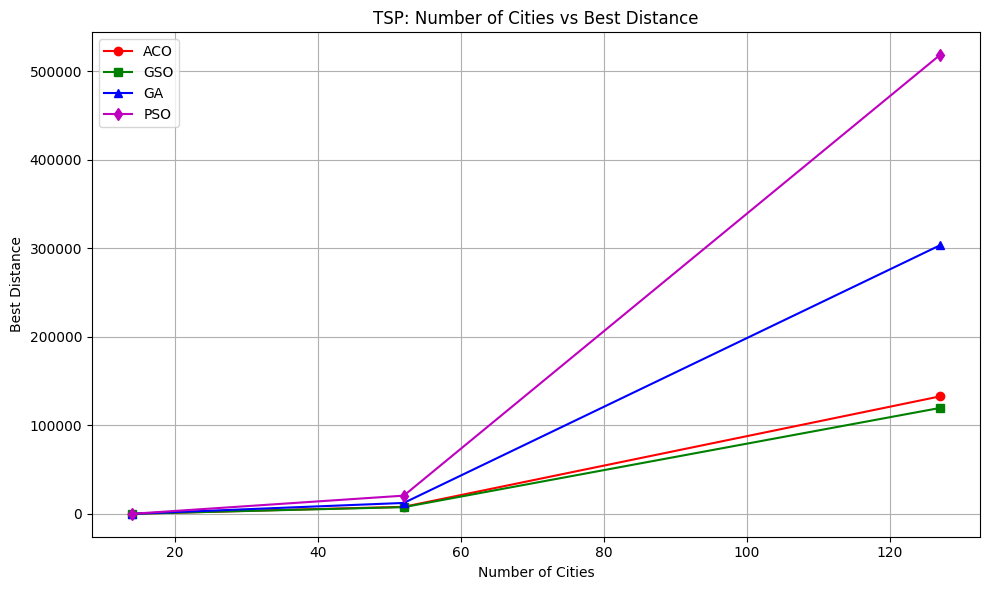

In [ ]:
import random
import math
import time
import numpy as np

# Global variables
n = 48
MAX_ITERATIONS = 200
NUM_GLOWWORMS = 50
GAMMA = 0.6

# Distance matrix representing distances between cities
distanceMatrix = []

class Glowworm:
    def __init__(self):
        self.tour = []
        self.brightness = 0.0

def calculateDistance(tour):
    totalDistance = 0.0
    for i in range(len(tour) - 1):
        totalDistance += distanceMatrix[tour[i]][tour[i + 1]]
    totalDistance += distanceMatrix[tour[-1]][tour[0]]  # Return to starting city
    return totalDistance

def initializeGlowworms():
    glowworms = []
    for i in range(NUM_GLOWWORMS):
        newGlowworm = Glowworm()
        newGlowworm.tour = list(range(len(distanceMatrix)))
        random.shuffle(newGlowworm.tour[1:])  # Shuffle cities except starting city
        newGlowworm.brightness = 1.0 / calculateDistance(newGlowworm.tour)
        glowworms.append(newGlowworm)
    return glowworms

def swapTwoCities(tour, city1, city2):
    tour[city1], tour[city2] = tour[city2], tour[city1]

def gso(coords, n_agents=30, iterations=50, luciferin_decay=0.4, luciferin_enhance=0.6, neighborhood_range=5):
    global distanceMatrix
    n = len(coords)
    distanceMatrix = np.array([[euclidean_distance(coords[i], coords[j]) for j in range(n)] for i in range(n)])

    glowworms = initializeGlowworms()
    best_path, best_distance = None, float('inf')

    start_time = time.time()

    # Perform Glowworm Swarm Optimization
    for iter in range(MAX_ITERATIONS):
        # Update glowworm positions and brightness
        totalBrightness = sum(gw.brightness for gw in glowworms)
        for i in range(NUM_GLOWWORMS):
            # Glowworm Movement
            decisionRange = GAMMA * glowworms[i].brightness / totalBrightness
            neighborIndices = []

            for j in range(NUM_GLOWWORMS):
                if i != j and calculateDistance(glowworms[j].tour) < calculateDistance(glowworms[i].tour) + decisionRange:
                    neighborIndices.append(j)

            if neighborIndices:
                selectedNeighborIndex = random.choice(neighborIndices)
                city1 = random.randint(1, len(glowworms[i].tour) - 1)  # Exclude the starting city
                city2 = random.randint(1, len(glowworms[selectedNeighborIndex].tour) - 1)
                swapTwoCities(glowworms[i].tour, city1, city2)
                glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

            # Local Search (2-opt)
            bestTour = glowworms[i].tour
            bestDistance = calculateDistance(bestTour)
            for j in range(len(bestTour) - 1):
                for k in range(j + 1, len(bestTour)):
                    newTour = bestTour[:]
                    newTour[j:k+1] = reversed(newTour[j:k+1])
                    newDistance = calculateDistance(newTour)
                    if newDistance < bestDistance:
                        bestTour = newTour
                        bestDistance = newDistance
            glowworms[i].tour = bestTour
            glowworms[i].brightness = 1.0 / bestDistance

        # Sort glowworms based on brightness
        glowworms.sort(key=lambda x: x.brightness, reverse=True)

        # Update pheromone levels
        for i in range(NUM_GLOWWORMS):
            glowworms[i].brightness = 1.0 / calculateDistance(glowworms[i].tour)

    end_time = time.time()
    duration = (end_time - start_time) * 1000  # Duration in milliseconds
    print(f"Glowworm Swarm Optimization Time: {duration} ms")

    # Get the best solution
    bestGlowworm = max(glowworms, key=lambda gw: gw.brightness)

    # Output the best tour and distance
    best_distance = calculateDistance(bestGlowworm.tour)
    best_path = bestGlowworm.tour
    print("Best Path:", best_path)
    print("Total Tour Distance:", best_distance)

    return best_distance, best_path

# Integration with existing code:
# Add aco, ga, pso, and gso distances to the main loop where you process datasets

# --- Main ---
dataset_paths = ['/content/burma14.tsp','/content/berlin52.tsp', '/content/bier127.tsp',]
cities, aco_dists, gso_dists, ga_dists, pso_dists = [], [], [], [], []

for path in dataset_paths:
    if os.path.exists(path):
        coords = read_tsp_file(path)
        n = len(coords)
        print(f"\nRunning on {path} with {n} cities")
        d1, _ = aco(coords)
        d2, _ = gso(coords)
        d3, _ = genetic_algorithm(coords)
        d4, _ = pso(coords)

        print(f"ACO: {d1:.2f}, GSO: {d2:.2f}, GA: {d3:.2f}, PSO: {d4:.2f}")
        cities.append(n)
        aco_dists.append(d1)
        gso_dists.append(d2)
        ga_dists.append(d3)
        pso_dists.append(d4)
    else:
        print(f"Dataset not found: {path}")

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.plot(cities, aco_dists, 'o-r', label='ACO')
plt.plot(cities, gso_dists, 's-g', label='GSO')
plt.plot(cities, ga_dists, '^-b', label='GA')
plt.plot(cities, pso_dists, 'd-m', label='PSO')
plt.xlabel("Number of Cities")
plt.ylabel("Best Distance")
plt.title("TSP: Number of Cities vs Best Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
